In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('data/A_Z Handwritten Data.csv')

In [38]:
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

In [39]:
X.shape, y.shape

((372450, 784), (372450,))

This dataset contains all alphabets (A to Z) but the aim of our classifier is to only classify letters X and O. Therefore we must select only datapoints of X and O

In [40]:
#index of o in the dataset = 14, index of x = 23
selected_index = [14, 23]
mask = np.isin(y, selected_index)
X = X[mask]
y = y[mask]

In [41]:
X.shape, y.shape

((64097, 784), (64097,))

In [42]:
y = np.where(y == 14, 0, 1)

In [43]:
labels, counts = np.unique(y, return_counts=True)
for label, count in zip(labels, counts):
    print(f"Label: {label}, count: {count}")

Label: 0, count: 57825
Label: 1, count: 6272


The current dataset is imbalanced with more O than X. Therefore we fix that imbalance


In [44]:
X = X[50825:]
y = y[50825:]

In [45]:
X.shape, y.shape

((13272, 784), (13272,))

In [46]:
labels, counts = np.unique(y, return_counts=True)
for label, count in zip(labels, counts):
    print(f"Label: {label}, count: {count}")

Label: 0, count: 7000
Label: 1, count: 6272


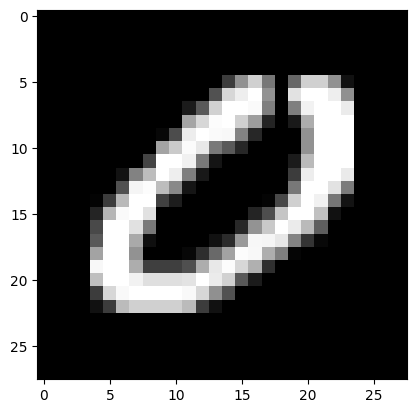

In [49]:
plt.imshow(X[0].reshape(28, 28), cmap='gray')

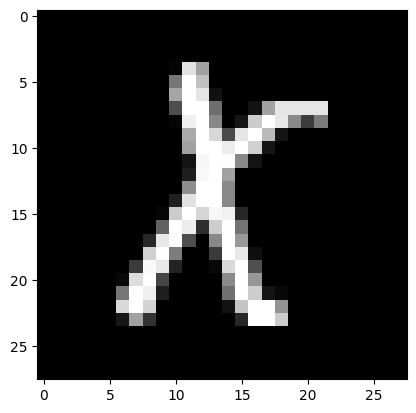

In [55]:
plt.imshow(X[7000].reshape(28, 28), cmap='gray')

In [56]:
import torch
import torch.nn as nn
from torch.optim import SGD
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [137]:
#class 0
X0_val = X[:100]
y0_val = y[:100]

X0_train = X[100:7000]
y0_train = y[100:7000]

#class 1
X1_val = X[7001:7101]
y1_val = y[7001:7101]

X1_train = X[7101:]
y1_train = y[7101:]

X_val = np.concatenate([X0_val, X1_val])
y_val = np.concatenate([y0_val, y1_val])

X_train = np.concatenate([X0_train, X1_train])
y_train = np.concatenate([y0_train, y1_train])

In [117]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((13071, 784), (200, 784), (13071,), (200,))

In [83]:
class MyDataset(Dataset):
    def __init__(self, X, y):
        X = X.reshape(-1, 1, 28, 28)
        X = X / 255.0
        X = torch.tensor(X).to(device).float()
        y = torch.tensor(y).to(device).float()
        y = y.unsqueeze(1)
        self.X = X
        self.y = y
    def __getitem__(self, item):
        return self.X[item], self.y[item]
    def __len__(self):
        return len(self.X)

In [84]:
def get_model():
    model = nn.Sequential(
        nn.Conv2d(1, 32, 3),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, 3),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, 3),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Flatten(),

        nn.Linear(128, 64),
        nn.ReLU(),

        nn.Linear(64, 1),
        nn.Sigmoid()
    ).to(device)

    loss_fn = nn.BCELoss()
    optimizer = SGD(model.parameters(), lr=0.001)
    return model, loss_fn, optimizer

In [61]:
def get_data(dataset):
    train_dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

    return train_dataloader, val_dataloader

In [95]:
@torch.no_grad()
def accuracy(X, y, model):
    prediction = model(X)
    is_correct = (prediction > 0.5) == y
    is_correct = is_correct.float().mean()
    return is_correct.item()

In [85]:
def train_batch(model, optimizer, loss_fn, X, y):
    model.train()
    output = model(X)
    loss = loss_fn(output, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return loss.item()

In [120]:
train_dataset = MyDataset(X_train, y_train)
val_dataset = MyDataset(X_val, y_val)

In [121]:
train_dl = get_data(train_dataset)
val_dl = get_data(val_dataset)

In [122]:
model, loss_fn, optimizer = get_model()

In [123]:
train_losses, train_accuracies = [], []
val_accuracies = []

In [127]:
for epoch in range(20):
    train_epoch_loss = []
    train_epoch_accuracy = []
    val_epoch_accuracy = []
    for idx, batch in enumerate(train_dl):
        batch_x, batch_y = batch
        loss = train_batch(model, optimizer, loss_fn, batch_x, batch_y)
        train_epoch_loss.append(loss)
    train_epoch_loss = np.mean(train_epoch_loss)

    for idx, batch in enumerate(train_dl):
        batch_x, batch_y = batch
        is_correct = accuracy(batch_x, batch_y, model)
        train_epoch_accuracy.append(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracy)

    for idx, batch in enumerate(val_dl):
        batch_x, batch_y = batch
        is_correct = accuracy(batch_x, batch_y, model)
        val_epoch_accuracy.append(is_correct)
    val_epoch_accuracy = np.mean(val_epoch_accuracy)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_accuracies.append(val_epoch_accuracy)


In [128]:
train_accuracies

[np.float64(0.5282396088311025),
 np.float64(0.5280664222164667),
 np.float64(0.5276334556070108),
 np.float64(0.5282396088311025),
 np.float64(0.5278066422216466),
 np.float64(0.5278066422216466),
 np.float64(0.5280664222164667),
 np.float64(0.5718826406013703),
 np.float64(0.7760238386599534),
 np.float64(0.9191524042476943),
 np.float64(0.9709657701711492),
 np.float64(0.9875458435207825),
 np.float64(0.99190097799511),
 np.float64(0.9935055012224939),
 np.float64(0.9938111246943765),
 np.float64(0.9942695599022005),
 np.float64(0.9944223716381418),
 np.float64(0.9946515892420538),
 np.float64(0.9947279951100244),
 np.float64(0.9947178076706772),
 np.float64(0.9950336185819071),
 np.float64(0.9951100244498777),
 np.float64(0.9951864303178484),
 np.float64(0.9952628361858191),
 np.float64(0.9951864303178484)]

In [129]:
val_accuracies

[np.float64(0.5133928571428571),
 np.float64(0.5),
 np.float64(0.5),
 np.float64(0.5267857142857143),
 np.float64(0.5),
 np.float64(0.48660714285714285),
 np.float64(0.5),
 np.float64(0.5089285714285714),
 np.float64(0.7857142857142857),
 np.float64(0.9241071428571429),
 np.float64(0.9642857142857143),
 np.float64(0.9955357142857143),
 np.float64(0.9955357142857143),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0)]

We reached a training accuracy of 99% and a validaion accuracy of 100% after 20 epochs

In [136]:
torch.save(model.state_dict(), 'models/model.pth')

In [138]:
#saving the validation dataset to be used to test the api
dataframe = pd.DataFrame(X_val)
dataframe['y'] = y_val
dataframe.to_csv("data/val_data.csv", index=False)